# CS336 Assignment 1 — Walkthrough Notebook

This notebook walks through every component we built, in the same order as the roadmap.  
The goal is to understand *why* each piece exists and *how* it fits into the full language model pipeline.

**Big picture:** We are building a GPT-style language model completely from scratch:
1. **Tokenizer** — convert raw text → sequences of integer IDs
2. **Neural network building blocks** — the layers that process those IDs
3. **Transformer architecture** — stack the blocks into a full model
4. **Training utilities** — the optimizer, loss, and schedule that teach the model

By the end, we can feed a sentence in, get logits out, and train the model to predict the next token.

In [5]:
import sys, os
# Make sure the package is importable from this notebook location
sys.path.insert(0, os.path.abspath('.'))

import torch
import numpy as np
import math

torch.manual_seed(42)
print('PyTorch:', torch.__version__)
print('Device available:', 'mps' if torch.backends.mps.is_available() else
      'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.12.0
Device available: mps


---
## Part 1 — BPE Tokenizer

### What problem does it solve?

A neural network can only work with numbers, not strings.  
We need to map text → integers and back.

**Why not just use characters?** English has ~100 printable characters.  
The model would need very long sequences to represent words, making training slow.

**Why not use whole words?** Vocabulary explodes (100k+ words), rare words get no training signal,  
and new words ("ChatGPT") are completely unknown.

**BPE (Byte-Pair Encoding)** is a middle ground:
- Start with the 256 raw bytes as the base vocabulary
- Repeatedly find the most frequent adjacent pair and merge it into one new token
- Stop when you reach the desired vocabulary size

The result is a vocabulary where common words are single tokens,  
rare words are split into pieces, and *any* byte sequence is representable.

In [6]:
from cs336_basics.tokenizer.tokenizer import train_bpe, BPETokenizer

# Train a tiny BPE tokenizer on the test corpus so we can see it work
CORPUS = 'tests/fixtures/corpus.en'
SPECIAL = ['<|endoftext|>']

vocab, merges = train_bpe(
    input_path=CORPUS,
    vocab_size=400,
    special_tokens=SPECIAL,
)

print(f'Vocabulary size: {len(vocab)}')
print(f'Number of merges learned: {len(merges)}')
print()
# Show a few of the first merges — these are the most frequent byte pairs
print('First 10 merges (most frequent byte pairs):')
for a, b in merges[:10]:
    print(f'  {repr(a)} + {repr(b)} → {repr(a + b)}')

100%|██████████| 143/143 [00:00<00:00, 1040.85it/s]

[TIME] train_bpe took 0.19s
Vocabulary size: 400
Number of merges learned: 143

First 10 merges (most frequent byte pairs):
  b' ' + b't' → b' t'
  b' ' + b'a' → b' a'
  b'h' + b'e' → b'he'
  b'i' + b'n' → b'in'
  b' t' + b'he' → b' the'
  b'r' + b'e' → b're'
  b' ' + b'o' → b' o'
  b' ' + b',' → b' ,'
  b'e' + b'r' → b'er'
  b' ' + b's' → b' s'


In [7]:
# Build the tokenizer from the vocab and merges we just trained
tokenizer = BPETokenizer(vocab, merges, special_tokens=SPECIAL)

# Encode some text
text = 'Hello, world! This is a language model.'
ids = tokenizer.encode(text)
print('Original text :', repr(text))
print('Token IDs     :', ids)
print('Num tokens    :', len(ids), '(vs', len(text), 'characters)')

# Decode back — should be identical
decoded = tokenizer.decode(ids)
print('Decoded       :', repr(decoded))
print('Round-trip OK :', text == decoded)

Original text : 'Hello, world! This is a language model.'
Token IDs     : [72, 316, 108, 111, 44, 272, 271, 382, 33, 32, 84, 104, 270, 309, 258, 298, 290, 103, 117, 396, 101, 287, 368, 316, 46]
Num tokens    : 25 (vs 39 characters)
Decoded       : 'Hello, world! This is a language model.'
Round-trip OK : True


In [8]:
# Special tokens are preserved as single units — they never get split
text_with_special = 'First story.<|endoftext|>Second story.'
ids2 = tokenizer.encode(text_with_special)

# Find where the special token lives in the output
eot_id = tokenizer.vocab_inv[b'<|endoftext|>']
print(f'<|endoftext|> token ID: {eot_id}')
print(f'Token IDs: {ids2}')
print(f'Special token appears at position: {ids2.index(eot_id)}')
print('Decoded:', repr(tokenizer.decode(ids2)))

<|endoftext|> token ID: 256
Token IDs: [70, 342, 319, 380, 271, 121, 46, 256, 83, 101, 99, 111, 269, 380, 271, 121, 46]
Special token appears at position: 7
Decoded: 'First story.<|endoftext|>Second story.'


In [9]:
# encode_iterable streams line-by-line — important for huge files
# that don't fit in RAM
lines = ['The cat sat on the mat.\n', 'The dog ran in the park.\n']
streamed_ids = list(tokenizer.encode_iterable(lines))
batch_ids = []
for line in lines:
    batch_ids.extend(tokenizer.encode(line))

print('Streaming == batch:', streamed_ids == batch_ids)

Streaming == batch: True


---
## Part 2 — Neural Network Building Blocks

We build every layer by hand, without using `torch.nn.Linear` or `torch.nn.Embedding`.  
This forces us to understand what each piece actually does mathematically.

### 2a — Linear Layer

The most fundamental operation in deep learning: a matrix multiply.

$$\text{output} = x W^\top$$

where $W$ has shape `(out_features, in_features)` — the PyTorch convention.  
We match this shape so `load_state_dict()` works with reference checkpoints.

In [10]:
from cs336_basics.modules.linear import Linear

# A simple linear projection: 4-dim input → 8-dim output
linear = Linear(in_features=4, out_features=8)
print('Weight shape:', linear.weight.shape)   # (8, 4) — out × in

x = torch.randn(3, 4)   # batch of 3 vectors, each of dim 4
out = linear(x)
print('Input  shape:', x.shape)
print('Output shape:', out.shape)   # (3, 8)

# It also handles arbitrary leading dimensions (e.g. batch × seq)
x_seq = torch.randn(2, 10, 4)
out_seq = linear(x_seq)
print('Seq input  :', x_seq.shape, '→', out_seq.shape)

Weight shape: torch.Size([8, 4])
Input  shape: torch.Size([3, 4])
Output shape: torch.Size([3, 8])
Seq input  : torch.Size([2, 10, 4]) → torch.Size([2, 10, 8])


### 2b — Embedding Layer

Turns integer token IDs into dense vectors.  
Conceptually it's just a lookup table: row `i` of the weight matrix is the embedding for token `i`.

This is how the model converts the tokenizer's output (integers) into something it can compute with.

In [31]:
from cs336_basics.modules.embedding import Embedding

# Embeddings convert discrete token IDs into continuous vectors.
# Each token ID indexes one row of the embedding table.
# The model processes these vectors, not the raw integer IDs.
#
# - VOCAB_SIZE = number of distinct token IDs the tokenizer produces
# - D_MODEL = embedding dimension; each token becomes a vector of this length
VOCAB_SIZE = 400
D_MODEL    = 32   # embedding dimension (small for demo)

embedding = Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=D_MODEL)
print('Embedding table shape:', embedding.weight.shape)  # (400, 32)

# Look up the embeddings for a batch of token sequences
token_ids = torch.tensor([[1, 5, 23, 7], [0, 3, 15, 42]])
embeds = embedding(token_ids)
print('Token IDs shape  :', token_ids.shape)
print('Embeddings shape :', embeds.shape)   # (2, 4, 32)

# The embedding for token 5 is just the 5th row of the weight matrix
print('\nDirect lookup matches:', torch.allclose(embeds[0, 1], embedding.weight[5]))

Embedding table shape: torch.Size([400, 32])
Token IDs shape  : torch.Size([2, 4])
Embeddings shape : torch.Size([2, 4, 32])

Direct lookup matches: True


### 2c — RMSNorm

Normalization stabilizes training by keeping activations at a reasonable scale.

**RMSNorm** is simpler than LayerNorm — it only divides by the root-mean-square, no centering:

$$\text{RMSNorm}(x) = \frac{x}{\sqrt{\frac{1}{d}\sum_i x_i^2 + \epsilon}} \cdot \gamma$$

The learnable scale $\gamma$ lets the model undo the normalization if needed.  
We compute the norm in `float32` even for `bf16` inputs to avoid overflow.

In [12]:
from cs336_basics.modules.norm import RMSNorm

norm = RMSNorm(d_model=D_MODEL)

# Before normalization: activations can have large variance
x_raw = torch.randn(2, 4, D_MODEL) * 10   # deliberately large scale
x_normed = norm(x_raw)

print(f'Input  std (per example): {x_raw[0].std().item():.3f}')
print(f'Output std (per example): {x_normed[0].std().item():.3f}')
print('Output shape:', x_normed.shape)
print('Weights initialized to 1:', norm.weight.mean().item())

Input  std (per example): 10.553
Output std (per example): 1.004
Output shape: torch.Size([2, 4, 32])
Weights initialized to 1: 1.0


### 2d — SiLU and SwiGLU

Every Transformer block has a Feed-Forward Network (FFN) — a small 2-layer MLP applied  
independently to each token position. Modern LLMs use **SwiGLU** instead of plain ReLU.

**SiLU** (Sigmoid Linear Unit) is the activation inside SwiGLU:
$$\text{SiLU}(x) = x \cdot \sigma(x)$$

**SwiGLU** adds a gating mechanism — one path goes through SiLU, another is a plain linear,  
and they are multiplied together element-wise before the down-projection:
$$\text{SwiGLU}(x) = W_2\big(\text{SiLU}(W_1 x) \odot W_3 x\big)$$

This gating lets the network *selectively* pass information through the FFN.

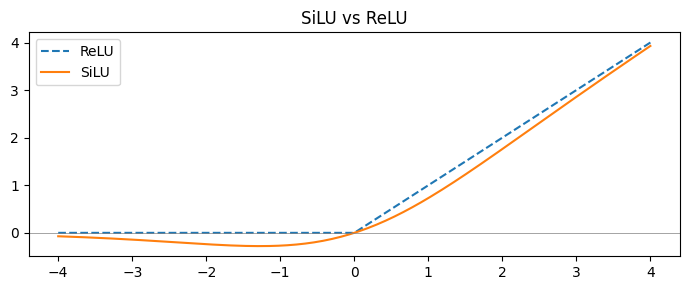

Key difference: SiLU is smooth and allows slightly negative values


In [13]:
from cs336_basics.modules.ffn import silu, SwiGLU
import matplotlib.pyplot as plt

# Visualize SiLU vs ReLU
x_plot = torch.linspace(-4, 4, 200)
relu_out = torch.relu(x_plot)
silu_out = silu(x_plot)

plt.figure(figsize=(7, 3))
plt.plot(x_plot, relu_out.detach(), label='ReLU', linestyle='--')
plt.plot(x_plot, silu_out.detach(), label='SiLU')
plt.axhline(0, color='gray', linewidth=0.5)
plt.title('SiLU vs ReLU')
plt.legend(); plt.tight_layout(); plt.show()
print('Key difference: SiLU is smooth and allows slightly negative values')

In [14]:
# SwiGLU FFN
D_FF = 128   # inner dimension of the FFN (typically 4× or 8/3× of d_model)
ffn = SwiGLU(d_model=D_MODEL, d_ff=D_FF)

print('w1 (gate, into SiLU):', ffn.w1.weight.shape)   # (d_ff, d_model)
print('w2 (down-proj)      :', ffn.w2.weight.shape)   # (d_model, d_ff)
print('w3 (up-proj)        :', ffn.w3.weight.shape)   # (d_ff, d_model)

x_in = torch.randn(2, 4, D_MODEL)
x_out = ffn(x_in)
print('\nFFN input  shape:', x_in.shape)
print('FFN output shape:', x_out.shape)   # same shape — FFN is position-wise

w1 (gate, into SiLU): torch.Size([128, 32])
w2 (down-proj)      : torch.Size([32, 128])
w3 (up-proj)        : torch.Size([128, 32])

FFN input  shape: torch.Size([2, 4, 32])
FFN output shape: torch.Size([2, 4, 32])


---
## Part 3 — Attention and RoPE

### 3a — Scaled Dot-Product Attention

Attention is the mechanism that lets tokens communicate with each other.  
Each token produces a **Query** (what am I looking for?),  
a **Key** (what do I offer?), and a **Value** (what information do I carry?).

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

The $\sqrt{d_k}$ scaling prevents the dot products from getting so large  
that the softmax saturates into a one-hot vector.

For a **causal** (autoregressive) model, the mask is a lower-triangular matrix  
so token $i$ can only attend to positions $0, 1, \ldots, i$ — never the future.

In [15]:
from cs336_basics.modules.attention import stable_softmax, scaled_dot_product_attention

# --- Numerically stable softmax ---
# Naive softmax can overflow with large values
large_logits = torch.tensor([1000.0, 1001.0, 1002.0])
print('Stable softmax on large logits:', stable_softmax(large_logits, dim=0))
# torch.exp(1000) would be inf, but we subtract the max first

Stable softmax on large logits: tensor([0.0900, 0.2447, 0.6652])


Q/K/V shape: torch.Size([2, 6, 16])
Output shape: torch.Size([2, 6, 16])


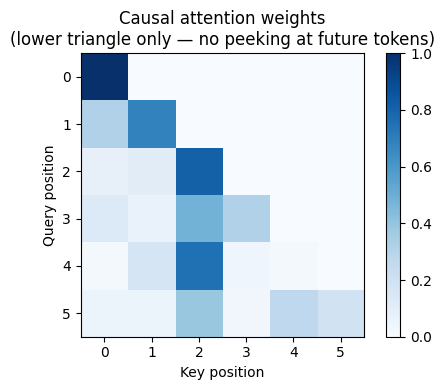

In [16]:
# --- Scaled dot-product attention ---
BATCH, SEQ, D_K, D_V = 2, 6, 16, 16

Q = torch.randn(BATCH, SEQ, D_K)
K = torch.randn(BATCH, SEQ, D_K)
V = torch.randn(BATCH, SEQ, D_V)

# Causal mask: token i attends to positions 0..i only
causal_mask = torch.tril(torch.ones(SEQ, SEQ, dtype=torch.bool)).unsqueeze(0)

out = scaled_dot_product_attention(Q, K, V, mask=causal_mask)
print('Q/K/V shape:', Q.shape)
print('Output shape:', out.shape)   # (batch, seq, d_v) — same sequence length

# Visualize the attention pattern of the first example
import matplotlib.pyplot as plt
scores = (Q[0] @ K[0].T) / math.sqrt(D_K)
scores_masked = scores.masked_fill(~causal_mask[0], float('-inf'))
attn_weights = torch.softmax(scores_masked, dim=-1)

plt.figure(figsize=(5, 4))
plt.imshow(attn_weights.detach(), cmap='Blues')
plt.title('Causal attention weights\n(lower triangle only — no peeking at future tokens)')
plt.xlabel('Key position'); plt.ylabel('Query position')
plt.colorbar(); plt.tight_layout(); plt.show()

### 3b — Rotary Positional Embeddings (RoPE)

Attention is permutation-invariant by default — it doesn't know which token came first.  
We need to inject position information.

**RoPE** rotates each query/key vector by an angle that depends on the token's position.  
The key insight: when you take the dot product $Q_m \cdot K_n$,  
the result only depends on the *relative* distance $m - n$, not the absolute positions.  
This is ideal for generalizing to sequences longer than those seen during training.

The rotation is applied to consecutive pairs $(x_{2i}, x_{2i+1})$:
$$\begin{pmatrix} x_{2i}' \\ x_{2i+1}' \end{pmatrix} =
\begin{pmatrix} \cos(m\theta_i) & -\sin(m\theta_i) \\ \sin(m\theta_i) & \cos(m\theta_i) \end{pmatrix}
\begin{pmatrix} x_{2i} \\ x_{2i+1} \end{pmatrix}$$

where $\theta_i = 1 / 10000^{2i/d_k}$ is a geometric frequency schedule.

In [17]:
from cs336_basics.modules.rope import RoPEEmbedding

rope = RoPEEmbedding(theta=10000.0, d_k=D_K, max_seq_len=128)

# Apply RoPE to a query tensor — shape (batch, seq, d_k)
q = torch.randn(BATCH, SEQ, D_K)
positions = torch.arange(SEQ).unsqueeze(0).expand(BATCH, -1)  # (batch, seq)
q_rotated = rope(q, positions)

print('Input  shape:', q.shape)
print('Output shape:', q_rotated.shape)   # same — RoPE is a rotation, not a projection

# Verify: the norm is preserved (rotation doesn't change length)
print(f'Norm before: {q[0, 0].norm().item():.4f}')
print(f'Norm after : {q_rotated[0, 0].norm().item():.4f}')

Input  shape: torch.Size([2, 6, 16])
Output shape: torch.Size([2, 6, 16])
Norm before: 3.2440
Norm after : 3.2440


### 3c — Multi-Head Attention (MHA)

Instead of one big attention computation, we run **h** smaller ones in parallel ("heads").  
Each head can learn to attend to different aspects of the input.  
The outputs are concatenated and projected back to `d_model`.

All Q/K/V projections for all heads are fused into a single matrix multiply  
of shape `(d_model, d_model)` — this is more efficient than h separate `(d_k, d_model)` matrices.

In [18]:
from cs336_basics.modules.attention import MHA

NUM_HEADS = 4
# d_model must be divisible by num_heads — each head gets d_k = d_model / num_heads dims
assert D_MODEL % NUM_HEADS == 0
D_HEAD = D_MODEL // NUM_HEADS
print(f'd_model={D_MODEL}, num_heads={NUM_HEADS}, d_k per head={D_HEAD}')

mha = MHA(d_model=D_MODEL, num_heads=NUM_HEADS, use_rope=True, theta=10000.0, max_seq_len=128)

# Print the projection weight names — these match the reference state dict exactly
for name, param in mha.named_parameters():
    print(f'  {name:30s} {tuple(param.shape)}')

d_model=32, num_heads=4, d_k per head=8
  q_proj.weight                  (32, 32)
  k_proj.weight                  (32, 32)
  v_proj.weight                  (32, 32)
  output_proj.weight             (32, 32)


In [19]:
# Run a forward pass
SEQ_LEN = 8
x = torch.randn(2, SEQ_LEN, D_MODEL)   # (batch, seq, d_model)

with torch.no_grad():
    out = mha(x)

print('MHA input  shape:', x.shape)
print('MHA output shape:', out.shape)   # same shape — attention is a sequence transform

MHA input  shape: torch.Size([2, 8, 32])
MHA output shape: torch.Size([2, 8, 32])


---
## Part 4 — Transformer Block and Full LM

### 4a — Transformer Block

A single block is two sub-layers, each with a **residual connection** and **pre-norm**:

```
x = x + Attention(RMSNorm(x))   ← attention sub-layer
x = x + FFN(RMSNorm(x))         ← feed-forward sub-layer
```

**Why residual connections?** They allow gradients to flow directly back through the network  
without passing through all the non-linearities. This is what makes deep models trainable.

**Why pre-norm (norm before the sub-layer)?** It stabilizes training more reliably than  
post-norm, which was used in the original Transformer.

In [20]:
from cs336_basics.model import TransformerBlock

block = TransformerBlock(
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    max_seq_len=128,
    theta=10000.0,
)

print('TransformerBlock sub-modules:')
for name, module in block.named_children():
    print(f'  {name}: {type(module).__name__}')

x = torch.randn(2, SEQ_LEN, D_MODEL)
with torch.no_grad():
    y = block(x)
print('\nBlock input  shape:', x.shape)
print('Block output shape:', y.shape)   # same — blocks preserve shape

TransformerBlock sub-modules:
  ln1: RMSNorm
  attn: MHA
  ln2: RMSNorm
  ffn: SwiGLU

Block input  shape: torch.Size([2, 8, 32])
Block output shape: torch.Size([2, 8, 32])


### 4b — Full Transformer Language Model

The full model stacks N blocks and adds:

1. **Token embedding** — map integer IDs → d_model vectors
2. **N × TransformerBlock** — contextualize each token using all others
3. **Final RMSNorm** — normalize the output of the last block
4. **LM head** — project d_model → vocab_size logits (one per possible next token)

The output logits are *unnormalized log-probabilities*. To get a probability distribution,  
apply softmax. To generate the next token, sample from that distribution.

In [21]:
from cs336_basics.model import TransformerLM

model = TransformerLM(
    vocab_size=VOCAB_SIZE,
    context_length=128,
    d_model=D_MODEL,
    num_layers=2,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    rope_theta=10000.0,
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print()

# Show the full state dict structure
print('State dict keys:')
for name, tensor in model.state_dict().items():
    print(f'  {name:45s} {tuple(tensor.shape)}')

Total parameters: 58,528

State dict keys:
  token_embeddings.weight                       (400, 32)
  layers.0.ln1.weight                           (32,)
  layers.0.attn.q_proj.weight                   (32, 32)
  layers.0.attn.k_proj.weight                   (32, 32)
  layers.0.attn.v_proj.weight                   (32, 32)
  layers.0.attn.output_proj.weight              (32, 32)
  layers.0.ln2.weight                           (32,)
  layers.0.ffn.w1.weight                        (128, 32)
  layers.0.ffn.w2.weight                        (32, 128)
  layers.0.ffn.w3.weight                        (128, 32)
  layers.1.ln1.weight                           (32,)
  layers.1.attn.q_proj.weight                   (32, 32)
  layers.1.attn.k_proj.weight                   (32, 32)
  layers.1.attn.v_proj.weight                   (32, 32)
  layers.1.attn.output_proj.weight              (32, 32)
  layers.1.ln2.weight                           (32,)
  layers.1.ffn.w1.weight                        (128,

In [22]:
# Run a forward pass: token IDs → logits
BATCH_SIZE = 2
in_ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))

with torch.no_grad():
    logits = model(in_ids)

print('Input  (token IDs) :', in_ids.shape,   '  dtype:', in_ids.dtype)
print('Output (logits)    :', logits.shape,   '  dtype:', logits.dtype)
print()
print('For each of the', SEQ_LEN, 'positions, the model outputs a score for each of the', VOCAB_SIZE, 'tokens.')
print('The highest-scoring token at each position is the model\'s predicted next token.')

# Turn logits into probabilities for the first position of the first example
probs = torch.softmax(logits[0, 0], dim=-1)
top5_probs, top5_ids = probs.topk(5)
print()
print('Top-5 predicted next tokens after position 0:')
for prob, tid in zip(top5_probs.tolist(), top5_ids.tolist()):
    print(f'  token {tid:4d}  prob {prob:.4f}')

Input  (token IDs) : torch.Size([2, 8])   dtype: torch.int64
Output (logits)    : torch.Size([2, 8, 400])   dtype: torch.float32

For each of the 8 positions, the model outputs a score for each of the 400 tokens.
The highest-scoring token at each position is the model's predicted next token.

Top-5 predicted next tokens after position 0:
  token   73  prob 0.0035
  token  349  prob 0.0034
  token  339  prob 0.0033
  token  148  prob 0.0033
  token  172  prob 0.0033


---
## Part 5 — Training Utilities

### 5a — Cross-Entropy Loss

The model outputs logits. We need a scalar loss to minimize.

**Cross-entropy** measures how surprised the model is by the correct next token:
$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \log p(\text{correct token at position } i)$$

We compute this in a numerically stable way using the log-sum-exp trick:
$$\log p_k = x_k - \log\sum_j e^{x_j} = (x_k - \max_j x_j) - \log\sum_j e^{x_j - \max_j x_j}$$

Subtracting the max before exponentiating prevents overflow.

In [23]:
from cs336_basics.training import cross_entropy_loss
import torch.nn.functional as F

# Toy example: 4 examples, 5 possible classes
logits = torch.tensor([
    [2.0, 1.0, 0.1, 0.5, 0.3],
    [0.1, 3.0, 0.2, 0.1, 0.1],
    [0.5, 0.5, 2.5, 0.5, 0.5],
    [0.1, 0.1, 0.1, 4.0, 0.1],
])
targets = torch.tensor([0, 1, 2, 3])   # correct class for each example

our_loss  = cross_entropy_loss(logits, targets)
ref_loss  = F.cross_entropy(logits, targets)
print(f'Our loss  : {our_loss.item():.6f}')
print(f'PyTorch   : {ref_loss.item():.6f}')
print(f'Match     : {torch.allclose(our_loss, ref_loss, atol=1e-5)}')

# Test numerical stability — naive exp(1000) = inf, but our implementation handles it
big_logits  = logits * 1000.0
our_big     = cross_entropy_loss(big_logits, targets)
ref_big     = F.cross_entropy(big_logits, targets)
print(f'\nWith 1000× logits — Our: {our_big.item():.6f}, PyTorch: {ref_big.item():.6f}')

Our loss  : 0.342048
PyTorch   : 0.342048
Match     : True

With 1000× logits — Our: 0.000000, PyTorch: 0.000000


### 5b — Batch Sampler

For language modeling, the label for each position is just the *next* token.
So if `x = [t0, t1, t2, ..., t_{L-1}]`, then `y = [t1, t2, ..., t_L]`.

We sample random starting positions from the token array so each batch sees different context.

In [24]:
from cs336_basics.training import get_batch

# Simulate a token array (in practice this would be the encoded training dataset)
fake_dataset = np.arange(200, dtype=np.int32)

x, y = get_batch(dataset=fake_dataset, batch_size=4, context_length=10, device='cpu')
print('Input  x:', x)
print('Labels y:', y)
print()
print('y is always x shifted by 1 token — the model predicts the next token at each position.')
print('Shift verified:', torch.all(y == x + 1).item())

Input  x: tensor([[108, 109, 110, 111, 112, 113, 114, 115, 116, 117],
        [156, 157, 158, 159, 160, 161, 162, 163, 164, 165],
        [ 34,  35,  36,  37,  38,  39,  40,  41,  42,  43],
        [140, 141, 142, 143, 144, 145, 146, 147, 148, 149]])
Labels y: tensor([[109, 110, 111, 112, 113, 114, 115, 116, 117, 118],
        [157, 158, 159, 160, 161, 162, 163, 164, 165, 166],
        [ 35,  36,  37,  38,  39,  40,  41,  42,  43,  44],
        [141, 142, 143, 144, 145, 146, 147, 148, 149, 150]])

y is always x shifted by 1 token — the model predicts the next token at each position.
Shift verified: True


### 5c — AdamW Optimizer

AdamW is the standard optimizer for transformer training.  
It combines two ideas:

**Adam**: maintain a running mean (m) and variance (v) of the gradients.  
This gives each parameter its own adaptive learning rate:
$$\theta \leftarrow \theta - \frac{\alpha \hat{m}}{\sqrt{\hat{v}} + \epsilon}$$

**Weight decay (decoupled)**: separately shrink each parameter toward zero:
$$\theta \leftarrow \theta(1 - \alpha \lambda)$$

Decoupling weight decay from the gradient update ("AdamW" vs "Adam + L2")  
leads to better regularization in practice.

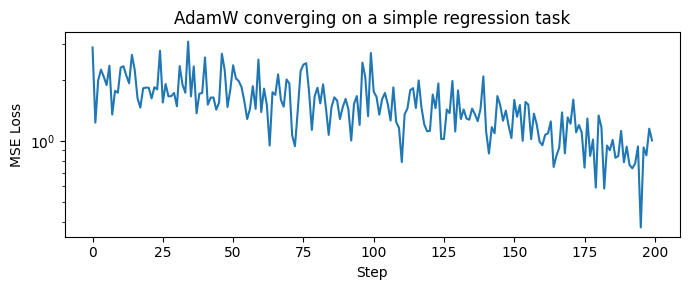

Final loss: 1.007259


In [25]:
from cs336_basics.training import AdamW

# Small 2-layer model to demonstrate optimization
demo_model = torch.nn.Sequential(
    torch.nn.Linear(4, 8),
    torch.nn.ReLU(),
    torch.nn.Linear(8, 1),
)

optimizer = AdamW(
    demo_model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.01,
)

losses = []
torch.manual_seed(0)
for step in range(200):
    x = torch.randn(32, 4)
    y = x[:, 0:1] + x[:, 1:2]   # learn y = x0 + x1
    pred = demo_model(x)
    loss = ((pred - y) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel('Step'); plt.ylabel('MSE Loss')
plt.title('AdamW converging on a simple regression task')
plt.yscale('log'); plt.tight_layout(); plt.show()
print(f'Final loss: {losses[-1]:.6f}')

### 5d — Cosine LR Schedule with Linear Warmup

A fixed learning rate is rarely optimal. We use a schedule with three phases:

1. **Linear warmup**: ramp from 0 to `max_lr` over `warmup_iters` steps  
   (avoids instability at the start when gradients are noisy)
2. **Cosine decay**: smoothly reduce from `max_lr` to `min_lr`  
   (following a cosine curve — slow at start/end, fast in the middle)
3. **Flat floor**: stay at `min_lr` forever after `cosine_cycle_iters`

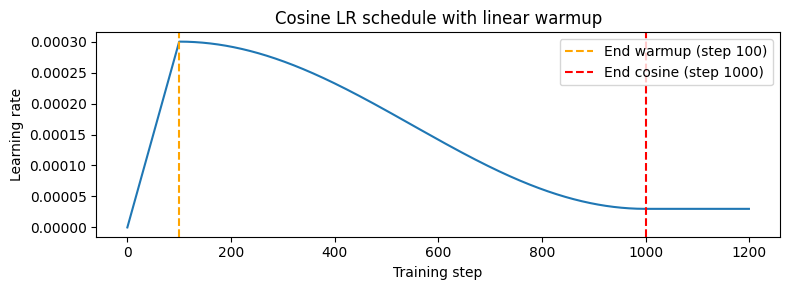

In [26]:
from cs336_basics.training import get_lr_cosine_schedule

MAX_LR    = 3e-4
MIN_LR    = 3e-5   # typically 10% of max
WARMUP    = 100
TOTAL     = 1000

steps = list(range(1200))
lrs   = [get_lr_cosine_schedule(t, MAX_LR, MIN_LR, WARMUP, TOTAL) for t in steps]

plt.figure(figsize=(8, 3))
plt.plot(steps, lrs)
plt.axvline(WARMUP,  color='orange', linestyle='--', label=f'End warmup (step {WARMUP})')
plt.axvline(TOTAL,   color='red',    linestyle='--', label=f'End cosine (step {TOTAL})')
plt.xlabel('Training step'); plt.ylabel('Learning rate')
plt.title('Cosine LR schedule with linear warmup')
plt.legend(); plt.tight_layout(); plt.show()

### 5e — Gradient Clipping

Sometimes a single bad batch can produce enormous gradients that destabilize training.  
Gradient clipping rescales **all** gradients together if their combined L2 norm exceeds a threshold:

$$g \leftarrow g \cdot \min\left(1, \frac{\text{max\_norm}}{\|g\|_2}\right)$$

This bounds the update step size without zeroing gradients, which would stop learning entirely.

In [27]:
from cs336_basics.training import gradient_clipping

# Create a parameter with a very large gradient
p1 = torch.nn.Parameter(torch.randn(5, 5))
p2 = torch.nn.Parameter(torch.randn(5, 5))
p1.grad = torch.ones(5, 5) * 10.0   # large gradient
p2.grad = torch.ones(5, 5) * 0.1    # small gradient

total_norm_before = math.sqrt(sum(p.grad.norm()**2 for p in [p1, p2]).item())

MAX_NORM = 1.0
gradient_clipping([p1, p2], max_l2_norm=MAX_NORM)

total_norm_after = math.sqrt(sum(p.grad.norm()**2 for p in [p1, p2]).item())
print(f'Combined L2 norm BEFORE clipping: {total_norm_before:.4f}')
print(f'Combined L2 norm AFTER  clipping: {total_norm_after:.4f}')
print(f'Clipped to max_norm={MAX_NORM}: {abs(total_norm_after - MAX_NORM) < 1e-5}')

Combined L2 norm BEFORE clipping: 50.0025
Combined L2 norm AFTER  clipping: 1.0000
Clipped to max_norm=1.0: True


### 5f — Checkpoint Save / Load

Training a large model takes hours. Checkpoints let us:
- Resume if training crashes
- Evaluate at different points during training
- Keep the best model across a hyperparameter sweep

We save **model weights + optimizer state + step count** into a single `.pt` file.

In [28]:
from cs336_basics.training import save_checkpoint, load_checkpoint
import tempfile, os

# Build a small model and run a few steps
small_model = TransformerLM(
    vocab_size=100, context_length=32, d_model=16,
    num_layers=1, num_heads=2, d_ff=32, rope_theta=10000.0
)
opt = AdamW(small_model.parameters(), lr=1e-3)

# Run 5 optimizer steps
for _ in range(5):
    ids = torch.randint(0, 100, (2, 8))
    logits = small_model(ids)
    loss = cross_entropy_loss(logits[:, :-1].reshape(-1, 100), ids[:, 1:].reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()

iteration = 5

# Save checkpoint
with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as f:
    ckpt_path = f.name
save_checkpoint(small_model, opt, iteration=iteration, out=ckpt_path)
print(f'Checkpoint saved: {os.path.getsize(ckpt_path):,} bytes')

# Restore into a fresh model and optimizer
new_model = TransformerLM(
    vocab_size=100, context_length=32, d_model=16,
    num_layers=1, num_heads=2, d_ff=32, rope_theta=10000.0
)
new_opt = AdamW(new_model.parameters(), lr=1e-3)
loaded_iter = load_checkpoint(ckpt_path, new_model, new_opt)

print(f'Loaded iteration: {loaded_iter}  (expected {iteration})')

# Verify weights match
for (n1, p1), (n2, p2) in zip(small_model.named_parameters(), new_model.named_parameters()):
    assert torch.allclose(p1, p2), f'Mismatch: {n1}'
print('All weights match after checkpoint restore ✓')
os.unlink(ckpt_path)

Checkpoint saved: 81,567 bytes
Loaded iteration: 5  (expected 5)
All weights match after checkpoint restore ✓


---
## Part 6 — End-to-End: Overfit a Single Batch

The classic sanity check before any real training run:  
**can the model memorize one batch?**

If loss doesn't go near zero on a single batch, something is broken  
(wrong loss function, incorrect gradient flow, layer bug, etc.).

This is the "Step 11" sanity check from the roadmap.

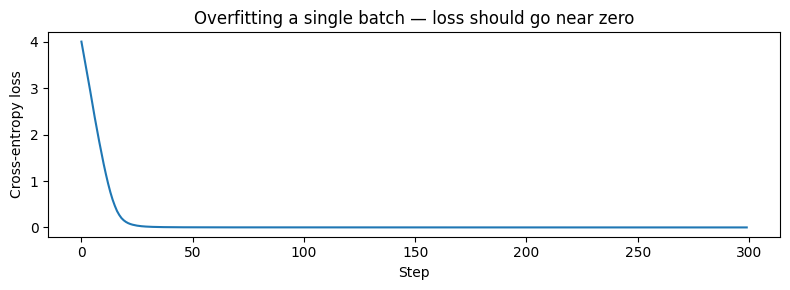

Initial loss : 4.0014  (expected ~log(50) = 3.91 for random model)
Final loss   : 0.0005  (should be close to 0)


In [29]:
# Tiny model — fast to train on CPU
toy_model = TransformerLM(
    vocab_size=50,
    context_length=16,
    d_model=32,
    num_layers=2,
    num_heads=4,
    d_ff=64,
    rope_theta=10000.0,
)
toy_opt = AdamW(toy_model.parameters(), lr=1e-2, weight_decay=0.0)

# Fix one batch — we want the model to memorize exactly this
torch.manual_seed(0)
fixed_ids = torch.randint(0, 50, (4, 16))   # (batch=4, seq=16)

overfit_losses = []
for step in range(300):
    logits = toy_model(fixed_ids)
    # Input: positions 0..14, Labels: positions 1..15
    loss = cross_entropy_loss(
        logits[:, :-1].reshape(-1, 50),
        fixed_ids[:, 1:].reshape(-1)
    )
    toy_opt.zero_grad()
    loss.backward()
    gradient_clipping(toy_model.parameters(), max_l2_norm=1.0)
    toy_opt.step()
    overfit_losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(overfit_losses)
plt.xlabel('Step'); plt.ylabel('Cross-entropy loss')
plt.title('Overfitting a single batch — loss should go near zero')
plt.tight_layout(); plt.show()

print(f'Initial loss : {overfit_losses[0]:.4f}  (expected ~log({50}) = {math.log(50):.2f} for random model)')
print(f'Final loss   : {overfit_losses[-1]:.4f}  (should be close to 0)')

---
## Part 7 — Text Generation

With a trained model we can generate text.  
The process is simple: run a forward pass, sample the next token, append it to the input, repeat.

Two sampling controls:
- **Temperature** (τ): divides logits before softmax. τ < 1 → sharper/more deterministic, τ > 1 → flatter/more random
- **Top-p (nucleus sampling)**: only sample from the smallest set of tokens whose total probability ≥ p. Prevents sampling very unlikely tokens.

In [30]:
# Use our BPE tokenizer + a random (untrained) model just to see the generation loop work
gen_model = TransformerLM(
    vocab_size=len(vocab),
    context_length=64,
    d_model=64,
    num_layers=2,
    num_heads=4,
    d_ff=128,
    rope_theta=10000.0,
)

# Encode a prompt
prompt = 'The'
prompt_ids = torch.tensor([tokenizer.encode(prompt)])
print('Prompt IDs:', prompt_ids)

# Generate 30 tokens
with torch.no_grad():
    output_ids = gen_model.generate(
        prompt_ids,
        max_new_tokens=30,
        temperature=0.8,
        top_p=0.9,
    )

generated_text = tokenizer.decode(output_ids[0].tolist())
print()
print('Generated (untrained model — random output):')
print(repr(generated_text))
print()
print('NOTE: Output is garbage because the model has random weights.')
print('After training on TinyStories, the model generates coherent children\'s stories.')

Prompt IDs: tensor([[ 84, 259]])

Generated (untrained model — random output):
'Theandf�all�"@chig�ctetes* .am\x11r�fV� he or ,��\x06is�'

NOTE: Output is garbage because the model has random weights.
After training on TinyStories, the model generates coherent children's stories.


---
## Summary: What We've Built

| Component | File | Role |
|-----------|------|------|
| `BPETokenizer` | `tokenizer/tokenizer.py` | Text ↔ token IDs |
| `Linear` | `modules/linear.py` | Core matrix multiply |
| `Embedding` | `modules/embedding.py` | ID → vector lookup |
| `RMSNorm` | `modules/norm.py` | Activation normalization |
| `SiLU / SwiGLU` | `modules/ffn.py` | Feed-forward sublayer |
| `RoPEEmbedding` | `modules/rope.py` | Positional encoding |
| `MHA` | `modules/attention.py` | Multi-head attention |
| `TransformerBlock` | `model.py` | One pre-norm block |
| `TransformerLM` | `model.py` | Full language model |
| `cross_entropy_loss` | `training.py` | Training objective |
| `get_batch` | `training.py` | Random batch sampler |
| `AdamW` | `training.py` | Optimizer |
| `get_lr_cosine_schedule` | `training.py` | LR schedule |
| `gradient_clipping` | `training.py` | Gradient norm clipping |
| `save/load_checkpoint` | `training.py` | Model persistence |

### Next Steps (Roadmap Steps 9–15)

1. **Download datasets** — TinyStories (~2GB) and OpenWebText (~40GB)
2. **Train the BPE tokenizer** on TinyStories, save vocab + merges
3. **Encode the dataset** — run `encode_iterable` and save as `.npy` memmap files
4. **Write the training loop** — ties all utilities together
5. **Run the baseline** — train a small Transformer on TinyStories, log loss curves
6. **Ablations** — compare RMSNorm vs no norm, pre-norm vs post-norm, RoPE vs NoPE, SwiGLU vs SiLU
7. **OpenWebText** — retrain on the harder dataset